<a href="https://colab.research.google.com/github/1k4r15/knn-car-price-prediction/blob/main/notebooks/01_exploracion_y_limpieza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción de Precios de Autos Usados con K-Nearest Neighbors (KNN)

**Objetivo:** predecir el precio de venta de un auto usado a partir de su año, kilometraje, marca, tipo de combustible, tipo de vendedor, transmisión y número de dueños anteriores.

**Dataset:** [Vehicle Dataset from CarDekho](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho) (Kaggle) — archivo `CAR DETAILS FROM CAR DEKHO.csv`.

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/1k4r15/knn-car-price-prediction/main/data/raw/CAR%20DETAILS%20FROM%20CAR%20DEKHO.csv"
df = pd.read_csv(url)

df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


## Exploración de Datos (EDA)

Antes de limpiar o modelar nada, reviso la estructura general del dataset: tipos de dato, valores nulos y estadísticas básicas.

In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


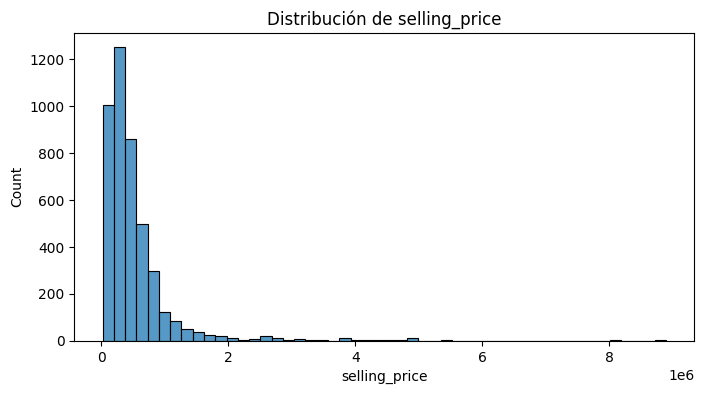

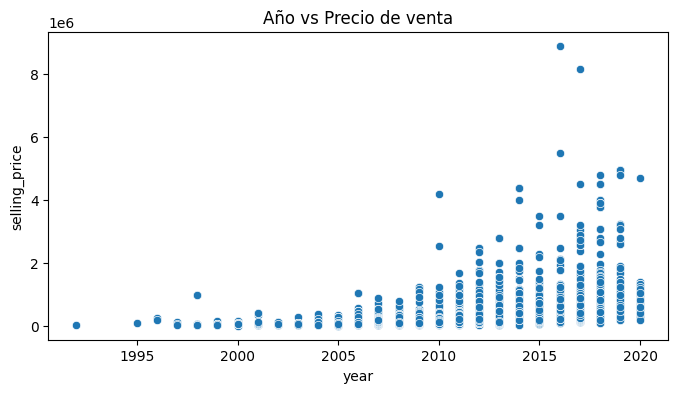

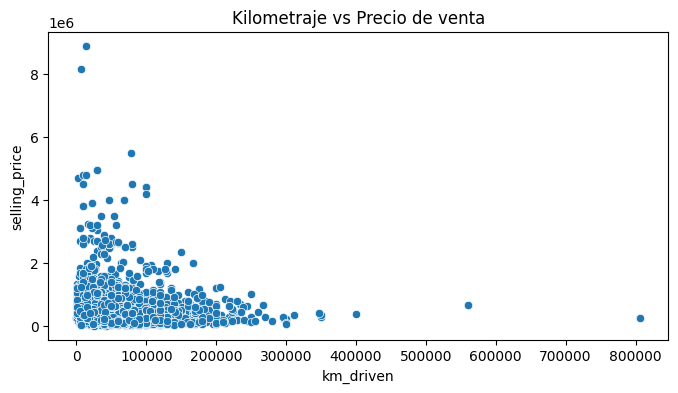

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribución de la variable objetivo
plt.figure(figsize=(8,4))
sns.histplot(df['selling_price'], bins=50)
plt.title('Distribución de selling_price')
plt.show()

# Año vs precio
plt.figure(figsize=(8,4))
sns.scatterplot(data=df, x='year', y='selling_price')
plt.title('Año vs Precio de venta')
plt.show()

# Kilometraje vs precio
plt.figure(figsize=(8,4))
sns.scatterplot(data=df, x='km_driven', y='selling_price')
plt.title('Kilometraje vs Precio de venta')
plt.show()

In [ ]:
print("name:", df['name'].nunique(), "valores únicos de", len(df), "filas")
print(df['fuel'].value_counts())
print(df['seller_type'].value_counts())
print(df['transmission'].value_counts())
print(df['owner'].value_counts())

name: 1491 valores únicos de 4340 filas
fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64
seller_type
Individual          3244
Dealer               994
Trustmark Dealer     102
Name: count, dtype: int64
transmission
Manual       3892
Automatic     448
Name: count, dtype: int64
owner
First Owner             2832
Second Owner            1106
Third Owner              304
Fourth & Above Owner      81
Test Drive Car            17
Name: count, dtype: int64


### Hallazgos de la exploración inicial

- El dataset no tiene valores nulos en ninguna columna.
- Hay 3 variables numéricas (`year`, `selling_price`, `km_driven`) y 5 categóricas.
- `selling_price` está fuertemente sesgado a la derecha: la mayoría de los autos cuestan menos de $1M, pero hay una cola larga de autos mucho más caros.
- `name` tiene 1,491 valores únicos en 4,340 filas — demasiadas categorías para usarla directamente.

## Limpieza de Datos: Revisión de Valores Atípicos

Antes de decidir si elimino algún dato "raro", reviso primero los extremos de precio y kilometraje para confirmar si son errores o casos legítimos.

In [ ]:
# Los 2 autos caros (8-9M) que se salen del resto del grupo
df[df['selling_price'] > 6000000]

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
89,Mercedes-Benz S-Class S 350d Connoisseurs Edition,2017,8150000,6500,Diesel,Dealer,Automatic,First Owner
3872,Audi RS7 2015-2019 Sportback Performance,2016,8900000,13000,Petrol,Dealer,Automatic,First Owner


In [ ]:
# El auto con ~800,000 km recorridos
df[df['km_driven'] > 500000]

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
525,Maruti SX4 S Cross DDiS 320 Delta,2016,665000,560000,Diesel,Dealer,Manual,First Owner
1243,Maruti Swift VXI BSIII,2009,250000,806599,Petrol,Dealer,Manual,First Owner
4184,Maruti SX4 S Cross DDiS 320 Delta,2016,665000,560000,Diesel,Dealer,Manual,First Owner


### Interpretación de los valores atípicos

Los 2 autos de más de $6M (Mercedes-Benz S-Class y Audi RS7) son autos de lujo reales, casi nuevos y con pocos kilómetros — datos legítimos, no errores. Los dejo en el dataset, aunque anticipo que van a ser difíciles de predecir bien por KNN (hay muy pocos autos similares para promediar).

El auto con ~806,599 km (un Maruti Swift 2009) también es extremo pero plausible. Tampoco lo elimino.

## Ingeniería de Características: Marca y Antigüedad del Dueño

`name` tiene demasiadas categorías únicas para codificarla directamente (generaría cientos de columnas casi vacías). La reduzco a la marca del auto. También codifico `owner` como variable ordinal, ya que representa un orden real que se perdería con one-hot encoding.

In [ ]:
df['brand'] = df['name'].apply(lambda x: x.split()[0])
print("Marcas únicas:", df['brand'].nunique())
print(df['brand'].value_counts())

Marcas únicas: 29
brand
Maruti           1280
Hyundai           821
Mahindra          365
Tata              361
Honda             252
Ford              238
Toyota            206
Chevrolet         188
Renault           146
Volkswagen        107
Skoda              68
Nissan             64
Audi               60
BMW                39
Fiat               37
Datsun             37
Mercedes-Benz      35
Mitsubishi          6
Jaguar              6
Land                5
Volvo               4
Ambassador          4
Jeep                3
OpelCorsa           2
MG                  2
Force               1
Daewoo              1
Isuzu               1
Kia                 1
Name: count, dtype: int64


In [ ]:
owner_map = {
    'Test Drive Car': 0,
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4
}
df['owner_encoded'] = df['owner'].map(owner_map)
df['owner_encoded'].value_counts()

,count
owner_encoded,
1,2832
2,1106
3,304
4,81
0,17


### Resultado de la ingeniería de características

`brand` quedó con 29 marcas únicas — mucho más manejable que las 1,491 categorías de `name`. `owner_encoded` mapea correctamente el orden original, con los 17 casos de "Test Drive Car" en 0.

## Detección de Duplicados

Al revisar el outlier de kilometraje, noté que uno de los autos aparecía dos veces con datos idénticos. Esto me hizo revisar si había más filas duplicadas en todo el dataset.

In [ ]:
print("Filas duplicadas en todo el dataset:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Filas después de eliminar duplicados:", len(df))

Filas duplicadas en todo el dataset: 763
Filas después de eliminar duplicados: 3577


### Hallazgo importante: filas duplicadas

**763 de las 4,340 filas (17.6% del dataset) eran duplicados exactos.** Las elimino, porque si no, esos autos repetidos "pesan doble" al entrenar el modelo sin ninguna razón real. El dataset queda en 3,577 filas.

## Agrupación de Marcas Poco Frecuentes y Codificación Final

Varias marcas tienen muy pocas apariciones (1-4 casos). Si las codifico tal cual, generan columnas casi vacías que no aportan información. Las agrupo en una categoría `"Other"`.

In [ ]:
umbral = 10
conteo_marcas = df['brand'].value_counts()
marcas_raras = conteo_marcas[conteo_marcas < umbral].index
df['brand'] = df['brand'].replace(marcas_raras, 'Other')
print(df['brand'].value_counts())

brand
Maruti           1072
Hyundai           637
Mahindra          328
Tata              308
Ford              220
Honda             216
Toyota            170
Chevrolet         151
Renault           110
Volkswagen         93
Nissan             52
Skoda              49
Other              33
Fiat               32
Audi               31
Datsun             29
BMW                25
Mercedes-Benz      21
Name: count, dtype: int64


In [ ]:
df_model = pd.get_dummies(df, columns=['brand', 'fuel', 'seller_type', 'transmission'], drop_first=True)
df_model = df_model.drop(columns=['name', 'owner'])

df_model.info()
df_model.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3577 entries, 0 to 3576
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   year                          3577 non-null   int64
 1   selling_price                 3577 non-null   int64
 2   km_driven                     3577 non-null   int64
 3   owner_encoded                 3577 non-null   int64
 4   brand_BMW                     3577 non-null   bool 
 5   brand_Chevrolet               3577 non-null   bool 
 6   brand_Datsun                  3577 non-null   bool 
 7   brand_Fiat                    3577 non-null   bool 
 8   brand_Ford                    3577 non-null   bool 
 9   brand_Honda                   3577 non-null   bool 
 10  brand_Hyundai                 3577 non-null   bool 
 11  brand_Mahindra                3577 non-null   bool 
 12  brand_Maruti                  3577 non-null   bool 
 13  brand_Mercedes-Benz           357

,year,selling_price,km_driven,owner_encoded,brand_BMW,brand_Chevrolet,brand_Datsun,brand_Fiat,brand_Ford,brand_Honda,...,brand_Tata,brand_Toyota,brand_Volkswagen,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual
0,2007,60000,70000,1,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,True
1,2007,135000,50000,1,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,True
2,2012,600000,100000,1,False,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,True
3,2017,250000,46000,1,False,False,True,False,False,False,...,False,False,False,False,False,False,True,True,False,True
4,2014,450000,141000,2,False,False,False,False,False,True,...,False,False,False,True,False,False,False,True,False,True


### Dataset listo para modelar

Tras codificar `brand`, `fuel`, `seller_type` y `transmission` con one-hot encoding (y eliminar `name` y `owner`, ya reemplazadas), el dataset queda con 27 columnas, todas numéricas.

## Preparación para el Modelado

Separo entrenamiento y prueba *antes* de normalizar, y ajusto el `StandardScaler` solo con los datos de entrenamiento. Si normalizara con todo el dataset junto, el modelo "vería" estadísticas del set de prueba antes de evaluarse con él (data leakage), inflando artificialmente mis métricas.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_model.drop(columns=['selling_price'])
y = df_model['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit SOLO con train
X_test_scaled = scaler.transform(X_test)          # test solo se transforma, nunca se "fitea"

print("Train:", X_train_scaled.shape, "| Test:", X_test_scaled.shape)

Train: (2861, 27) | Test: (716, 27)


## Modelo Baseline: KNN con k=5

Antes de optimizar nada, entreno un primer modelo con un valor de `k` arbitrario (5) para tener un punto de referencia contra el cual comparar las mejoras posteriores.

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE:  {mae:,.0f}")
print(f"RMSE: {rmse:,.0f}")

MAE:  171,232
RMSE: 422,842


In [ ]:
print("Precio promedio:", f"{y.mean():,.0f}")
print("Precio mediana:", f"{y.median():,.0f}")
print("MAE como % del precio promedio:", f"{mae / y.mean() * 100:.1f}%")

from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f"R²: {r2:.3f}")  # qué % de la variación del precio explica el modelo

Precio promedio: 473,913
Precio mediana: 350,000
MAE como % del precio promedio: 36.1%
R²: 0.445


In [ ]:
comparacion = pd.DataFrame({'real': y_test.values, 'prediccion': y_pred}, index=y_test.index)
print(comparacion[comparacion['real'] > 3000000])

         real  prediccion
538   3800000   1872800.0
2881  4800000   2620000.0
76    8150000   1552800.0
3341  5500000   1311800.0
88    4500000   1264800.0
927   3100000    584000.0


### Interpretación del modelo baseline

Con k=5, el modelo tiene un MAE de 171,232 (≈36% del precio promedio) y un R² de apenas 0.445. Al revisar los autos caros del set de prueba, el modelo los subestima de forma sistemática y creciente mientras más caro es el auto real: KNN no tiene suficientes autos de lujo "cercanos" para promediar bien en esa zona.

## Optimización de Hiperparámetros (k) con Validación Cruzada

En vez de probar valores de `k` al azar, uso Grid Search con validación cruzada K-Fold (5 folds) para encontrar el `k` que minimiza el error de forma más confiable que un solo split de entrenamiento/prueba.

In [ ]:
from sklearn.model_selection import GridSearchCV, KFold

param_grid = {'n_neighbors': range(1, 21)}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    KNeighborsRegressor(),
    param_grid,
    cv=kf,
    scoring='neg_root_mean_squared_error'
)
grid_search.fit(X_train_scaled, y_train)

print("Mejor k:", grid_search.best_params_['n_neighbors'])
print("RMSE en validación cruzada:", f"{-grid_search.best_score_:,.0f}")

Mejor k: 4
RMSE en validación cruzada: 298,995


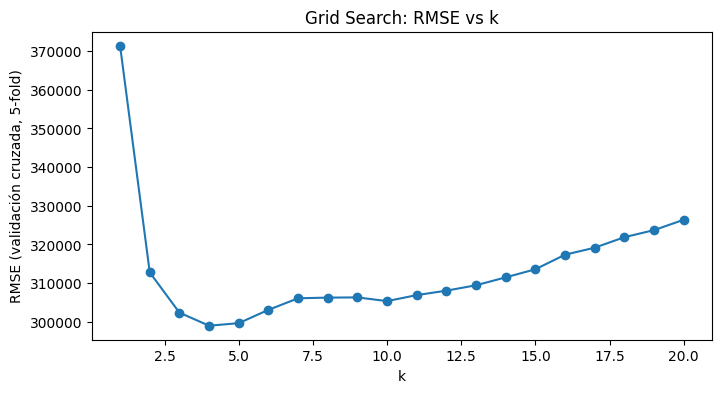

In [ ]:
import matplotlib.pyplot as plt

ks = list(param_grid['n_neighbors'])
rmse_por_k = -grid_search.cv_results_['mean_test_score']

plt.figure(figsize=(8,4))
plt.plot(ks, rmse_por_k, marker='o')
plt.xlabel('k')
plt.ylabel('RMSE (validación cruzada, 5-fold)')
plt.title('Grid Search: RMSE vs k')
plt.show()

### Interpretación del Grid Search

La curva de RMSE vs. k tiene la forma clásica en "U": alta en k=1 (sobreajuste), cae hasta un mínimo en k=4, y vuelve a subir lentamente hacia k=20 (subajuste). `k=4` ganó, aunque por un margen muy pequeño sobre valores cercanos — la curva está casi plana en ese rango.

## Evaluación del Modelo Optimizado

In [ ]:
# GridSearchCV ya re-entrenó automáticamente el mejor modelo en todo X_train
best_knn = grid_search.best_estimator_
y_pred_final = best_knn.predict(X_test_scaled)

mae_final = mean_absolute_error(y_test, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2_final = r2_score(y_test, y_pred_final)

print("--- Baseline (k=5, sin optimizar) vs Optimizado (k=4) ---")
print(f"{'Métrica':<10}{'Baseline':>15}{'Optimizado':>15}")
print(f"{'MAE':<10}{mae:>15,.0f}{mae_final:>15,.0f}")
print(f"{'RMSE':<10}{rmse:>15,.0f}{rmse_final:>15,.0f}")
print(f"{'R²':<10}{'—':>15}{r2_final:>15.3f}")

--- Baseline (k=5, sin optimizar) vs Optimizado (k=4) ---
Métrica          Baseline     Optimizado
MAE               171,232        169,516
RMSE              422,842        423,831
R²                      —          0.442


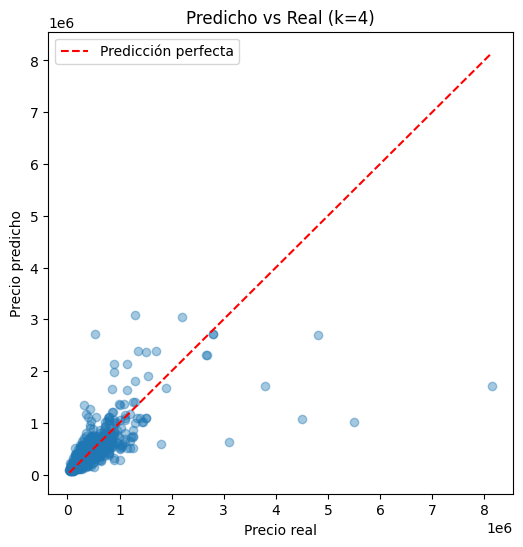

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_final, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Predicción perfecta')
plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.title(f'Predicho vs Real (k={grid_search.best_params_["n_neighbors"]})')
plt.legend()
plt.show()

### Interpretación del modelo optimizado

Pese a que la validación cruzada eligió k=4 como mejor valor, la mejora sobre el set de prueba real fue mínima: el MAE bajó apenas ~1%, mientras que el RMSE y el R² prácticamente no cambiaron. Esto confirma que el "techo" del modelo no está en `k` — está en la falta de datos suficientes para predecir bien los autos de lujo.

## Mejora Exploratoria: Transformación Logarítmica del Precio

Dado que `selling_price` está muy sesgado a la derecha, pruebo transformar la variable objetivo con logaritmo (`log1p`), una técnica estándar para este tipo de distribución.

In [ ]:
# Log-transform del target
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

grid_search_log = GridSearchCV(
    KNeighborsRegressor(),
    param_grid,
    cv=kf,
    scoring='neg_root_mean_squared_error'
)
grid_search_log.fit(X_train_scaled, y_train_log)

print("Mejor k (log):", grid_search_log.best_params_['n_neighbors'])

Mejor k (log): 6


In [ ]:
# Volver a la escala original para comparar en las mismas unidades que el baseline
best_knn_log = grid_search_log.best_estimator_
y_pred_log = best_knn_log.predict(X_test_scaled)
y_pred_log_orig = np.expm1(y_pred_log)  # inversa de log1p

mae_log = mean_absolute_error(y_test, y_pred_log_orig)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log_orig))
r2_log = r2_score(y_test, y_pred_log_orig)

print("--- Comparación final (todo en pesos, no en log) ---")
print(f"{'Métrica':<10}{'Optimizado k=4':>18}{'Log-transform':>18}")
print(f"{'MAE':<10}{mae_final:>18,.0f}{mae_log:>18,.0f}")
print(f"{'RMSE':<10}{rmse_final:>18,.0f}{rmse_log:>18,.0f}")
print(f"{'R²':<10}{r2_final:>18.3f}{r2_log:>18.3f}")

--- Comparación final (todo en pesos, no en log) ---
Métrica       Optimizado k=4     Log-transform
MAE                  169,516           166,211
RMSE                 423,831           417,416
R²                     0.442             0.459


In [ ]:
comparacion_log = pd.DataFrame({'real': y_test.values, 'prediccion': y_pred_log_orig}, index=y_test.index)
print(comparacion_log[comparacion_log['real'] > 3000000])

         real    prediccion
538   3800000  1.577176e+06
2881  4800000  2.653529e+06
76    8150000  1.577176e+06
3341  5500000  1.352393e+06
88    4500000  1.362443e+06
927   3100000  5.571605e+05


## Conclusiones

- **Calidad de datos:** se eliminaron 763 filas duplicadas (17.6% del dataset) — un hallazgo detectado al investigar un valor atípico de kilometraje.
- **Optimizar `k` no fue suficiente:** el Grid Search encontró una mejora casi nula sobre el set de prueba real.
- **La transformación logarítmica sí ayudó**, mejorando las tres métricas de forma consistente, aunque modesta.
- **La limitación principal persiste:** el modelo subestima sistemáticamente los autos de lujo. Dos autos del set de prueba con precios muy distintos ($3.8M y $8.15M) recibieron exactamente la misma predicción.
- **Próximos pasos:** probar modelos menos sensibles a zonas de baja densidad de datos (ej. Random Forest), o incorporar features más detalladas del auto.